# MovieLens 1M Dataset Exploration

First stop in the lab. Before building any recommender we need to understand the data we are working with: how it is structured, how sparse it is, and what biases it carries. Every algorithm we build later exists to solve a problem visible in this exploration.

## Setup

Load the three MovieLens tables through the shared loader. The loader downloads the dataset on first use, so the notebook is self-contained.

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "recommendation_lab").is_dir():
    ROOT = ROOT.parent
    if ROOT == ROOT.parent:
        raise RuntimeError("could not locate recommendation_lab package")
sys.path.insert(0, str(ROOT))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from recommendation_lab.data.loader import load_ml_1m

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

data = load_ml_1m()
ratings = data["ratings"]
users = data["users"]
movies = data["movies"]

Dataset 'ml-1m' already present at /Users/kayceejenz/Documents/experiment/recommendation-system-lab/data/ml-1m


## Overview

Explore the sasic shapes, dtypes, and missing values. The key number here is sparsity: the fraction of the user-movie matrix that is actually filled.

In [2]:
print(f"ratings: {ratings.shape[0]:,} rows")
print(f"users:   {users.shape[0]:,} rows")
print(f"movies:  {movies.shape[0]:,} rows")
print()
print("missing values per table:")
for name, df in data.items():
    print(f"  {name:8s} {df.isna().sum().to_dict()}")
print()
ratings.describe().round(2)

ratings: 1,000,209 rows
users:   6,040 rows
movies:  3,883 rows

missing values per table:
  ratings  {'user_id': 0, 'movie_id': 0, 'rating': 0, 'timestamp': 0}
  users    {'user_id': 0, 'gender': 0, 'age': 0, 'occupation': 0, 'zip_code': 0}
  movies   {'movie_id': 0, 'title': 0, 'genres': 0}



,user_id,movie_id,rating,timestamp
count,1000209.00,1000209.00,1000209.00,1.000209e+06
mean,3024.51,1865.54,3.58,9.722437e+08
std,1728.41,1096.04,1.12,1.215256e+07
min,1.00,1.00,1.00,9.567039e+08
25%,1506.00,1030.00,3.00,9.653026e+08
50%,3070.00,1835.00,4.00,9.730180e+08
75%,4476.00,2770.00,4.00,9.752209e+08
max,6040.00,3952.00,5.00,1.046455e+09


In [ ]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_rating = ratings.shape[0]

print(f"unique users:  {n_users:,}")
print(f"unique movies: {n_movies:,}")

sparsity = 1 -  n_rating/ (n_users * n_movies)

print(f"matrix sparsity: {sparsity:.4%} (filled: {1 - sparsity:.4%})")
print(f"average ratings per user:  {n_rating / n_users:.1f}")
print(f"average ratings per movie: {n_rating / n_movies:.1f}")

unique users:  6,040
unique movies: 3,706
matrix sparsity: 95.5316% (filled: 4.4684%)
average ratings per user:  165.6
average ratings per movie: 269.9


**Finding:**
1,000,209 ratings from 6,040 users over a 3,883 movie catalog, but only 3,706 movies were ever rated (177 never got a rating). The user-movie matrix is 95.5% empty (4.47% filled): most user-movie pairs carry no signal at all, and every collaborative algorithm we build will be fighting this.

## Rating distribution

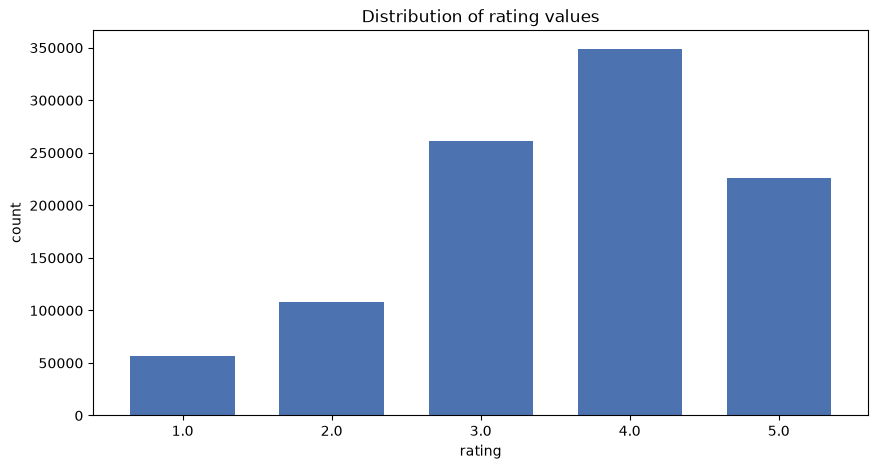

rating
1.0     56174
2.0    107557
3.0    261197
4.0    348971
5.0    226310
Name: count, dtype: int64


In [4]:
rating_counts = ratings["rating"].value_counts().sort_index()
rating_counts.plot(kind="bar", color="#4C72B0", width=0.7)
plt.title("Distribution of rating values")
plt.xlabel("rating")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()
print(rating_counts)

**Findings:**
Ratings are on a 1-5 integer scale where most reviews were around 3.0 and 4.0 being the most common value. Absolute prediction quality (RMSE, MAE) will be a weak metric, hence using ranking quality (NDCG, MAP, Hit Rate) is the honest one.

## User activity


count    6040.00
mean      165.60
std       192.75
min        20.00
25%        44.00
50%        96.00
75%       208.00
max      2314.00
users with <= 20 ratings: 86 (1.4%)


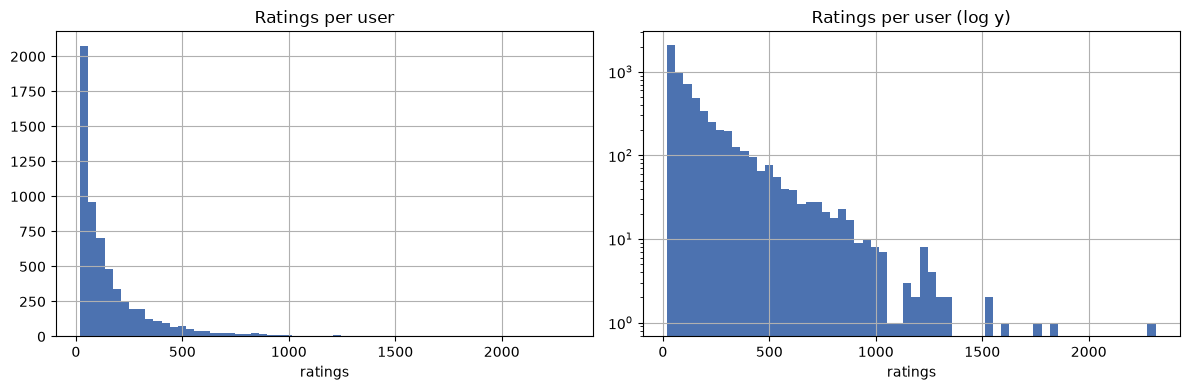

In [5]:
user_counts = ratings.groupby("user_id")["movie_id"].count()
print(user_counts.describe().round(2).to_string())
print(f"users with <= 20 ratings: {((user_counts <= 20).sum()):,} "
      f"({(user_counts <= 20).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
user_counts.hist(bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Ratings per user")
axes[0].set_xlabel("ratings")
user_counts.hist(bins=60, ax=axes[1], color="#4C72B0", log=True)
axes[1].set_title("Ratings per user (log y)")
axes[1].set_xlabel("ratings")
plt.tight_layout()
plt.show()

**Findings:**
Ratings per user range from 20 to 2,314 with a median of 96; only 1.4% of users have 20 or fewer. This shows that they is no genuine user cold start in ml-1m, but the bottom quartile (44 ratings or fewer) still gives neighborhood methods little to work with.

## Movie popularity


count    3706.00
mean      269.89
std       384.05
min         1.00
25%        33.00
50%       123.50
75%       350.00
max      3428.00
movies with <= 20 ratings: 695 (18.8%)


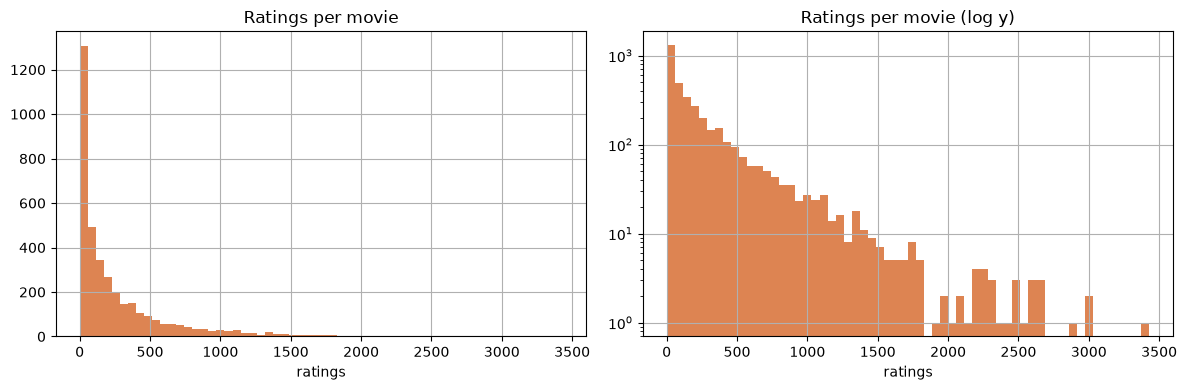

most rated movies:
                                                title  count
                               American Beauty (1999)   3428
            Star Wars: Episode IV - A New Hope (1977)   2991
Star Wars: Episode V - The Empire Strikes Back (1980)   2990
    Star Wars: Episode VI - Return of the Jedi (1983)   2883
                                 Jurassic Park (1993)   2672
                           Saving Private Ryan (1998)   2653
                    Terminator 2: Judgment Day (1991)   2649
                                   Matrix, The (1999)   2590
                            Back to the Future (1985)   2583
                     Silence of the Lambs, The (1991)   2578


In [6]:
movie_counts = ratings.groupby("movie_id")["user_id"].count()
print(movie_counts.describe().round(2).to_string())
print(f"movies with <= 20 ratings: {(movie_counts <= 20).sum():,} "
      f"({(movie_counts <= 20).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
movie_counts.hist(bins=60, ax=axes[0], color="#DD8452")
axes[0].set_title("Ratings per movie")
axes[0].set_xlabel("ratings")
movie_counts.hist(bins=60, ax=axes[1], color="#DD8452", log=True)
axes[1].set_title("Ratings per movie (log y)")
axes[1].set_xlabel("ratings")
plt.tight_layout()
plt.show()

top = movies[movies["movie_id"].isin(movie_counts.sort_values(ascending=False).head(10).index)]
top = top.merge(movie_counts.rename("count"), on="movie_id").sort_values("count", ascending=False)
print("most rated movies:")
print(top[["title", "count"]].to_string(index=False))

**Findings:**
ratings per movie range from 1 to 3,428 with a median of 123, and a handful of titles (American Beauty, the Star Wars trilogy, Jurassic Park) absorb a disproportionate share of interactions. A popularity recommender will be a deceptively strong baseline, but identical for every user: 18.8% of movies have 20 or fewer ratings and 177 have zero.

## Temporal analysis


span: 2000-04-25 23:05:32 -> 2003-02-28 17:49:50


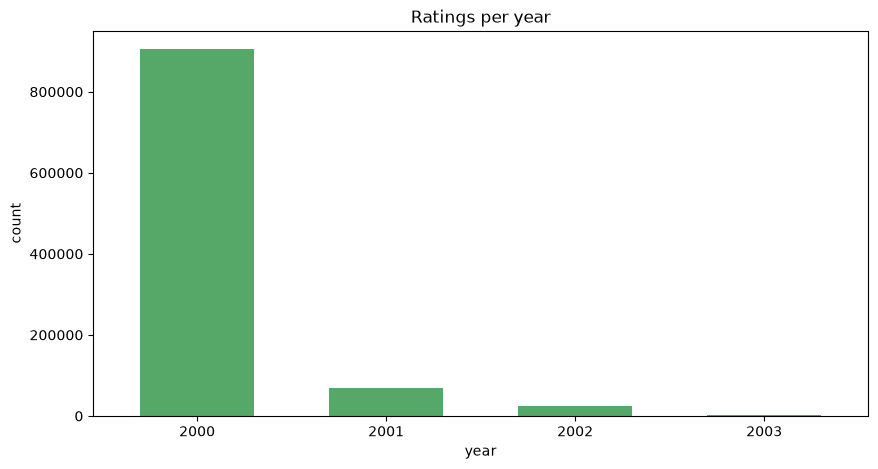

year
2000    904757
2001     68058
2002     24046
2003      3348
dtype: int64


In [7]:
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"] = ratings["date"].dt.year
print(f"span: {ratings['date'].min()} -> {ratings['date'].max()}")

by_year = ratings.groupby("year").size()
by_year.plot(kind="bar", color="#55A868", width=0.6)
plt.title("Ratings per year")
plt.xlabel("year")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()
print(by_year)

**Findings:**
The data spans from 2000-04 to 2003-02, and 90% of ratings fall in 2000. A random train/test split can let test ratings predate a user's own training ratings, silently inflating results. This is why time-based split must be considered using evaluation.

## Genres

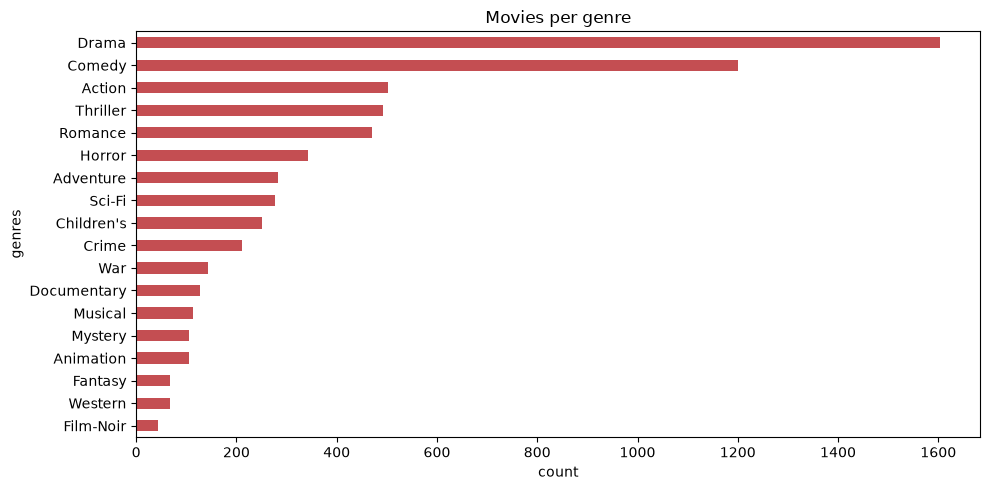

average genres per movie: 1.65
movies with one genre:    52.2%


In [8]:
genre_series = movies["genres"].explode()
genre_counts = genre_series.value_counts()
genre_counts.plot(kind="barh", color="#C44E52")
plt.title("Movies per genre")
plt.xlabel("count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

multi = movies["genres"].apply(len)
print(f"average genres per movie: {multi.mean():.2f}")
print(f"movies with one genre:    {(multi == 1).mean():.1%}")

**Finding:**
Genre is the only content signal, and it is weak: 1.65 genres per movie on average and 52.2% of movies carry a single genre. A content-based model here can only ever separate "Comedy" from "Drama" and friends, so it will underperform collaborative methods; there is no text or tag data to lean on.

## Demographics


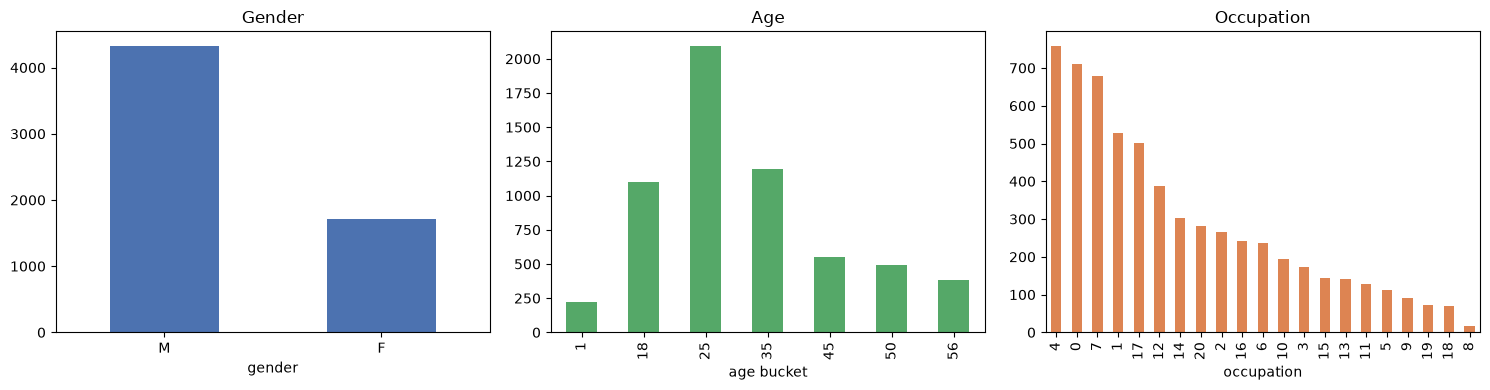

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
users["gender"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Gender")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
users["age"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Age")
axes[1].set_xlabel("age bucket")
users["occupation"].value_counts().plot(kind="bar", ax=axes[2], color="#DD8452")
axes[2].set_title("Occupation")
plt.tight_layout()
plt.show()

## Cold-start perspective

The two cold-start edges of the matrix: users with almost no history, and movies with almost no ratings. Quantifying both gives us a baseline for what *cold* means in this dataset, and a target for the algorithms that claim to mitigate it.

In [10]:
low_user = user_counts <= 10
low_movie = movie_counts <= 10
print(f"users with <= 10 ratings:  {low_user.sum():,} ({low_user.mean():.1%} of users)")
print(f"movies with <= 10 ratings: {low_movie.sum():,} ({low_movie.mean():.1%} of movies)")
print()
unrated = movies[~movies["movie_id"].isin(ratings["movie_id"].unique())]
print(f"movies with zero ratings:  {len(unrated)}")

users with <= 10 ratings:  0 (0.0% of users)
movies with <= 10 ratings: 473 (12.8% of movies)

movies with zero ratings:  177


**Findings:**
Item cold start is the real sparse edge: 473 movies have 10 or fewer ratings and 177 have zero. User cold start does not exist here. Neighborhood and factorization models will struggle to represent and surface these items, so cold-start handling must be item-focused.

Each stage of the lab exists to address one of these observations.